# 7-Day Demand Model Training (LightGBM vs XGBoost)

This notebook trains and compares two models on the 7-day aggregated dataset:
- LightGBM (primary candidate)
- XGBoost (challenger)

Evaluation KPIs in this notebook: **MAE, RMSE, SMAPE, BIAS, VA**.

Decisions already locked: **MAD removed**, **SL skipped for now**.

## 1) Setup and Imports
Load libraries, define file paths, and initialize configuration.

Expected output: no table yet, just a successful run with no import/path errors.

In [59]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
RANDOM_SEED = 42

try:
    from lightgbm import LGBMRegressor
except Exception as e:
    raise ImportError(
        'lightgbm is required. Install with: pip install lightgbm'
    ) from e

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError(
        'xgboost is required. Install with: pip install xgboost'
    ) from e

DATA_DIR = Path('../data/processed/LGBM_XGB_7_V1')
TRAIN_PATH = DATA_DIR / 'train.csv'
VAL_PATH = DATA_DIR / 'val.csv'
TEST_PATH = DATA_DIR / 'test.csv'

REPORTS_DIR = Path('../artifacts/reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

## 2) Load Data and Sanity Check
Read train/validation/test files and confirm shapes, date ranges, and null counts.

Expected output: one summary table with split sizes, date ranges, and null-cell counts.

In [60]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for _df in [train_df, val_df, test_df]:
    _df['date'] = pd.to_datetime(_df['date'], errors='coerce')

def split_summary(name, df):
    return {
        'split': name,
        'rows': len(df),
        'cols': df.shape[1],
        'min_date': df['date'].min(),
        'max_date': df['date'].max(),
        'null_cells': int(df.isna().sum().sum())
    }

summary = pd.DataFrame([
    split_summary('train', train_df),
    split_summary('val', val_df),
    split_summary('test', test_df),
])
summary

,split,rows,cols,min_date,max_date,null_cells
0,train,68976,21,2015-01-07,2015-12-02,0
1,val,14370,21,2015-12-09,2016-02-10,0
2,test,15807,21,2016-02-17,2016-04-24,0


## 3) Define Target and Feature Columns
Set the training schema (categorical, numeric, and event features) and build X/y for each split.

Expected output: printed feature count and split-ready X/y objects.

In [61]:
target_col = 'aggregated_sales_7'
categorical_features = ['item_id']
numeric_features = [
    'is_month_end',
    'sales_lag_7',
    'sales_roll_mean_7',
    'aggregated_sell_price',
    'discount_depth',
]
event_features = [
    'event_christmas_7',
    'event_easter_7',
    'event_eid_al_fitr_7',
    'event_eid_al_adha_7',
    'event_fathers_day_7',
    'event_halloween_7',
    'event_mothers_day_7',
    'event_newyear_7',
    'event_orthodox_christmas_7',
    'event_orthodox_easter_7',
    'event_ramadan_starts_7',
    'event_thanksgiving_7',
    'event_valentines_day_7',
]

feature_cols = categorical_features + numeric_features + event_features
required_cols = feature_cols + [target_col, 'date']

missing_train = sorted(set(required_cols) - set(train_df.columns))
missing_val = sorted(set(required_cols) - set(val_df.columns))
missing_test = sorted(set(required_cols) - set(test_df.columns))

if missing_train or missing_val or missing_test:
    raise ValueError({
        'missing_train': missing_train,
        'missing_val': missing_val,
        'missing_test': missing_test
    })

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(float).copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].astype(float).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(float).copy()

print('Feature count:', len(feature_cols))
print('Categorical:', categorical_features)
print('Numeric + event:', len(numeric_features + event_features))

Feature count: 19
Categorical: ['item_id']
Numeric + event: 18


## 4) Define Evaluation Metrics
Create helper functions for MAE, RMSE, SMAPE, BIAS, and VA calculations.

Expected output: no table yet, helper functions become available for later cells.

In [62]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))

def evaluate_metrics(y_true, y_pred, model_name, split_name, baseline_metrics=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s = smape(y_true, y_pred)
    b = bias(y_true, y_pred)

    out = {
        'model': model_name,
        'split': split_name,
        'MAE': mae,
        'RMSE': rmse,
        'SMAPE': s,
        'BIAS': b,
        'VA_MAE_pct': np.nan,
        'VA_SMAPE_pct': np.nan,
    }

    if baseline_metrics is not None:
        if baseline_metrics['MAE'] > 0:
            out['VA_MAE_pct'] = 100.0 * (baseline_metrics['MAE'] - mae) / baseline_metrics['MAE']
        if baseline_metrics['SMAPE'] > 0:
            out['VA_SMAPE_pct'] = 100.0 * (baseline_metrics['SMAPE'] - s) / baseline_metrics['SMAPE']

    return out

## 5) Baseline for Value Add (VA)
Use the naive lag-7 prediction as baseline on validation and test splits.

Expected output: baseline KPI table for val/test (used to compute VA percentages).

In [63]:
# Baseline for VA: previous 7-day demand (sales_lag_7)
baseline_val_pred = X_val['sales_lag_7'].astype(float).values
baseline_test_pred = X_test['sales_lag_7'].astype(float).values

baseline_val = evaluate_metrics(y_val, baseline_val_pred, 'NaiveLag7', 'val')
baseline_test = evaluate_metrics(y_test, baseline_test_pred, 'NaiveLag7', 'test')

baseline_table = pd.DataFrame([baseline_val, baseline_test])
baseline_table

,model,split,MAE,RMSE,SMAPE,BIAS,VA_MAE_pct,VA_SMAPE_pct
0,NaiveLag7,val,5.149687,11.092077,53.078788,-0.419137,NaN,NaN
1,NaiveLag7,test,5.369330,10.539058,54.037467,0.503638,NaN,NaN


## 6) Build Preprocessing Pipeline
Prepare categorical and numeric feature transformations for both models.

Expected output: a displayed ColumnTransformer summary.

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features + event_features),
    ],
    remainder='drop'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 7) Train LightGBM and Evaluate on Validation
Fit LightGBM on train split, predict validation, and compute KPIs.

Expected output: one-row LightGBM validation metrics table.

In [65]:
lgbm_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LGBMRegressor(
        random_state=RANDOM_SEED,
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9
    ))
])

lgbm_model.fit(X_train, y_train)
lgbm_val_pred = lgbm_model.predict(X_val)

lgbm_val_metrics = evaluate_metrics(
    y_val,
    lgbm_val_pred,
    model_name='LightGBM',
    split_name='val',
    baseline_metrics=baseline_val
)

pd.DataFrame([lgbm_val_metrics])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3705
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 1454
[LightGBM] [Info] Start training from score 14.243998


,model,split,MAE,RMSE,SMAPE,BIAS,VA_MAE_pct,VA_SMAPE_pct
0,LightGBM,val,5.242598,11.377975,76.132652,0.679937,-1.804215,-43.43329


## 8) Train XGBoost and Evaluate on Validation
Fit XGBoost on train split, predict validation, and compute KPIs.

Expected output: one-row XGBoost validation metrics table.

In [66]:
xgb_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBRegressor(
        random_state=RANDOM_SEED,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
xgb_val_pred = xgb_model.predict(X_val)

xgb_val_metrics = evaluate_metrics(
    y_val,
    xgb_val_pred,
    model_name='XGBoost',
    split_name='val',
    baseline_metrics=baseline_val
)

pd.DataFrame([xgb_val_metrics])

,model,split,MAE,RMSE,SMAPE,BIAS,VA_MAE_pct,VA_SMAPE_pct
0,XGBoost,val,5.192208,11.099756,75.897754,0.599439,-0.825712,-42.990744


## 9) Compare Models on Validation
Rank models and select the winner using the agreed KPI priority.

Expected output: ranked comparison table plus winner model name.

In [67]:
val_compare = pd.DataFrame([lgbm_val_metrics, xgb_val_metrics]).sort_values(
    by=['SMAPE', 'RMSE', 'BIAS'],
    ascending=[True, True, True],
).reset_index(drop=True)

winner_name = val_compare.loc[0, 'model']
winner_name
val_compare

,model,split,MAE,RMSE,SMAPE,BIAS,VA_MAE_pct,VA_SMAPE_pct
0,XGBoost,val,5.192208,11.099756,75.897754,0.599439,-0.825712,-42.990744
1,LightGBM,val,5.242598,11.377975,76.132652,0.679937,-1.804215,-43.433290


## 9B) Rolling Validation (Walk-Forward)
Run multiple time-based folds on pre-test data (train+val) for more stable model selection.

Expected output: fold-level KPI table, average KPI table by model, and rolling winner.

In [68]:
def build_model(model_name):
    prep = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features + event_features),
        ],
        remainder='drop'
    )

    if model_name == 'LightGBM':
        reg = LGBMRegressor(
            random_state=RANDOM_SEED,
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
        )
    elif model_name == 'XGBoost':
        reg = XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    else:
        raise ValueError(f'Unknown model: {model_name}')

    return Pipeline(steps=[('prep', prep), ('model', reg)])

pretest_df = pd.concat([train_df, val_df], ignore_index=True).copy()
pretest_df['date'] = pd.to_datetime(pretest_df['date'], errors='coerce')
pretest_df = pretest_df.sort_values('date').reset_index(drop=True)

unique_dates = np.array(sorted(pretest_df['date'].dropna().unique()))
val_window = len(np.array(sorted(val_df['date'].dropna().unique())))
min_train_windows = max(val_window, 8)

max_folds = (len(unique_dates) - min_train_windows) // max(1, val_window)
n_folds = int(min(4, max_folds))

if n_folds < 1:
    raise ValueError(
        f'Not enough timeline for rolling folds. unique_dates={len(unique_dates)}, val_window={val_window}'
    )

rolling_rows = []
for fold in range(n_folds):
    train_end = min_train_windows + fold * val_window
    val_start = train_end
    val_end = val_start + val_window

    train_dates = set(unique_dates[:train_end])
    valid_dates = set(unique_dates[val_start:val_end])

    fold_train = pretest_df[pretest_df['date'].isin(train_dates)].copy()
    fold_val = pretest_df[pretest_df['date'].isin(valid_dates)].copy()

    X_tr = fold_train[feature_cols].copy()
    y_tr = fold_train[target_col].astype(float).copy()
    X_va = fold_val[feature_cols].copy()
    y_va = fold_val[target_col].astype(float).copy()

    baseline_pred = X_va['sales_lag_7'].astype(float).values
    baseline_fold = evaluate_metrics(y_va, baseline_pred, 'NaiveLag7', f'fold_{fold+1}')

    for model_name in ['LightGBM', 'XGBoost']:
        model = build_model(model_name)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        m = evaluate_metrics(
            y_va, pred, model_name=model_name, split_name=f'fold_{fold+1}', baseline_metrics=baseline_fold
        )
        m['fold'] = fold + 1
        m['train_rows'] = len(fold_train)
        m['val_rows'] = len(fold_val)
        rolling_rows.append(m)

rolling_results = pd.DataFrame(rolling_rows)
rolling_summary = (
    rolling_results
    .groupby('model', as_index=False)[['MAE', 'RMSE', 'SMAPE', 'BIAS', 'VA_MAE_pct', 'VA_SMAPE_pct']]
    .mean()
)
rolling_summary['BIAS_abs'] = rolling_summary['BIAS'].abs()
rolling_summary = rolling_summary.sort_values(['SMAPE', 'RMSE', 'BIAS_abs'], ascending=[True, True, True]).reset_index(drop=True)

winner_name_rolling = rolling_summary.loc[0, 'model']
winner_name = winner_name_rolling

print(f'Rolling folds used: {n_folds}, validation window size: {val_window} dates')
rolling_results
rolling_summary[['model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'VA_MAE_pct', 'VA_SMAPE_pct']]
print('Rolling winner:', winner_name_rolling)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 14370, number of used features: 8
[LightGBM] [Info] Start training from score 13.911413
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3641
[LightGBM] [Info] Number of data points in the train set: 28740, number of used features: 1448
[LightGBM] [Info] Start training from score 14.192241
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3673
[LightGBM] [Info] Number of data points in the train s

## 10) Plot KPI Comparison
Visualize MAE, RMSE, and SMAPE across both models on validation.

Expected output: one bar chart comparing KPI values for LightGBM and XGBoost.

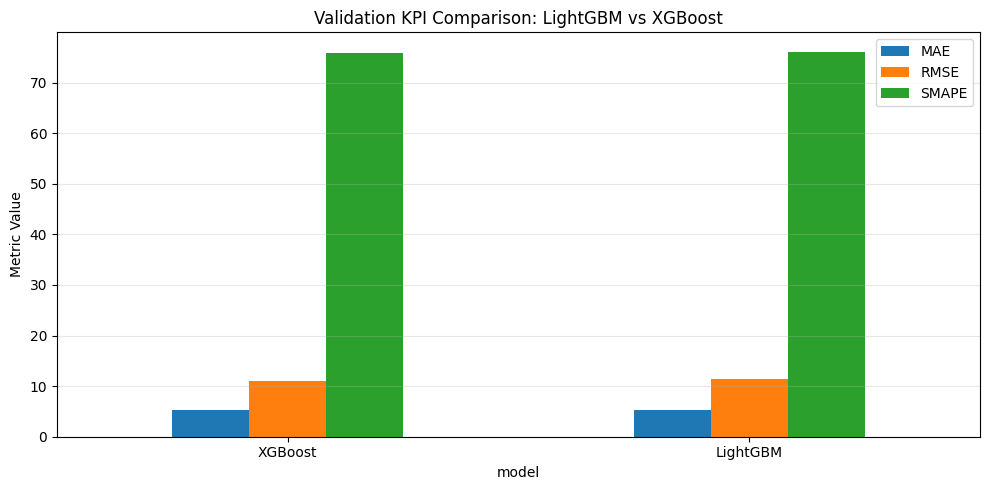

In [69]:
plot_df = val_compare[['model', 'MAE', 'RMSE', 'SMAPE']].set_index('model')
ax = plot_df.plot(kind='bar', figsize=(10, 5))
ax.set_title('Validation KPI Comparison: LightGBM vs XGBoost')
ax.set_ylabel('Metric Value')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11) Plot Actual vs Predicted Curves
Compare model forecasts against actual values for a few sample items.

Expected output: time-series line plots (Actual vs LightGBM vs XGBoost) for sample items.

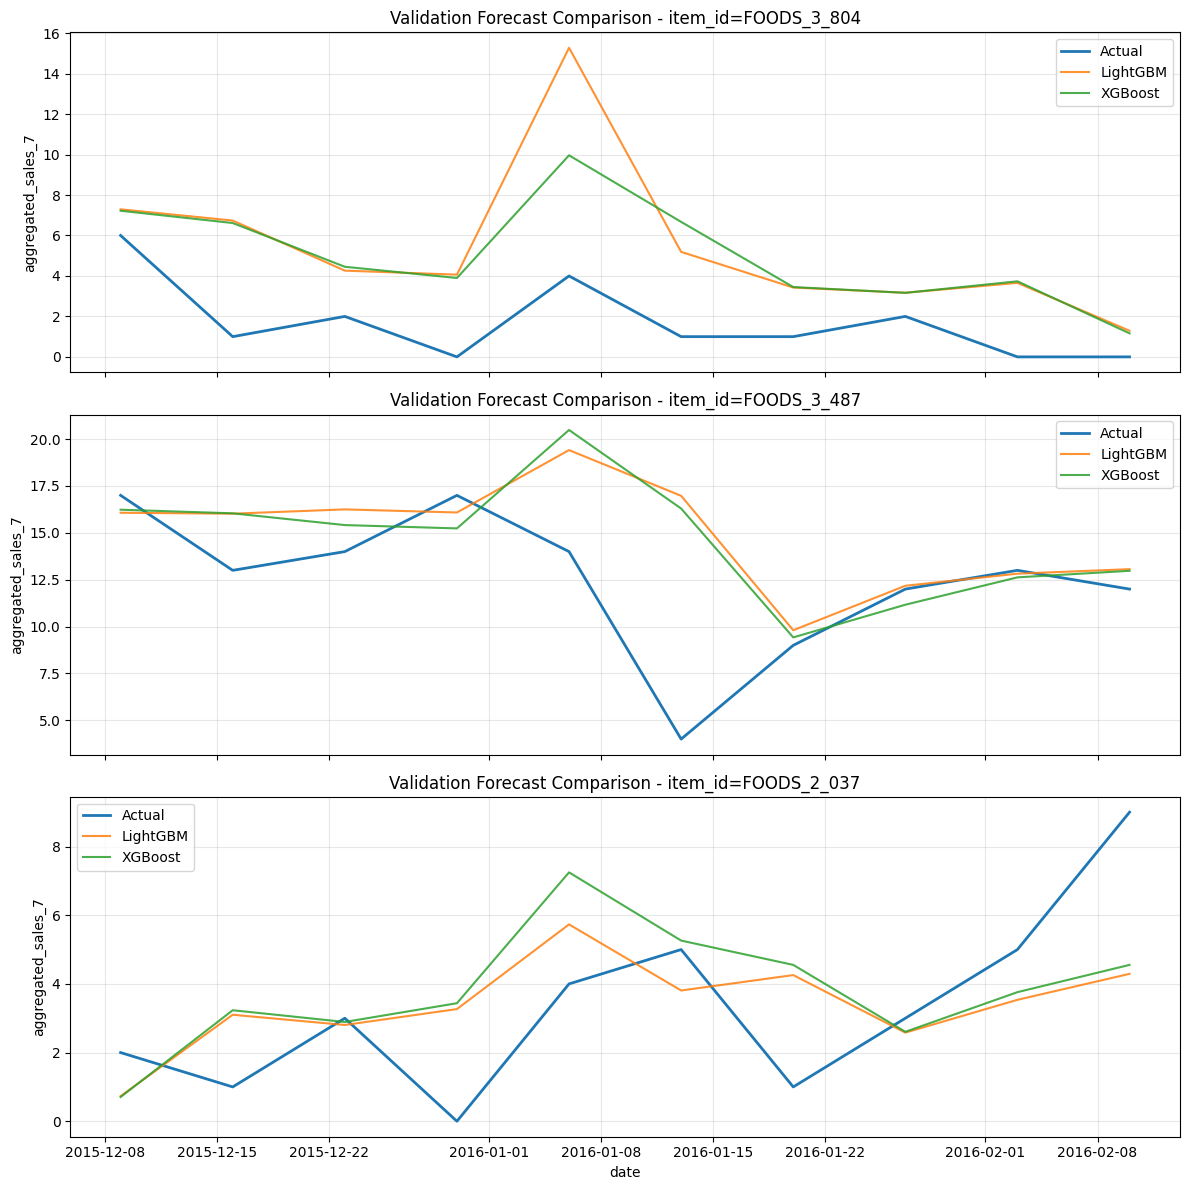

In [70]:
# Actual vs predicted for a few sample items on validation split
sample_items = val_df['item_id'].dropna().astype(str).value_counts().head(3).index.tolist()

plot_val = val_df[['item_id', 'date', target_col]].copy()
plot_val['pred_lgbm'] = lgbm_val_pred
plot_val['pred_xgb'] = xgb_val_pred

fig, axes = plt.subplots(len(sample_items), 1, figsize=(12, 4 * len(sample_items)), sharex=True)
if len(sample_items) == 1:
    axes = [axes]

for ax, item in zip(axes, sample_items):
    tmp = plot_val[plot_val['item_id'].astype(str) == item].sort_values('date')
    ax.plot(tmp['date'], tmp[target_col], label='Actual', linewidth=2)
    ax.plot(tmp['date'], tmp['pred_lgbm'], label='LightGBM', alpha=0.85)
    ax.plot(tmp['date'], tmp['pred_xgb'], label='XGBoost', alpha=0.85)
    ax.set_title(f'Validation Forecast Comparison - item_id={item}')
    ax.set_ylabel('aggregated_sales_7')
    ax.grid(alpha=0.3)
    ax.legend()

plt.xlabel('date')
plt.tight_layout()
plt.show()

## 12) Plot Residual Distribution
Inspect error spread and bias tendencies for both models.

Expected output: residual histogram overlays for LightGBM and XGBoost.

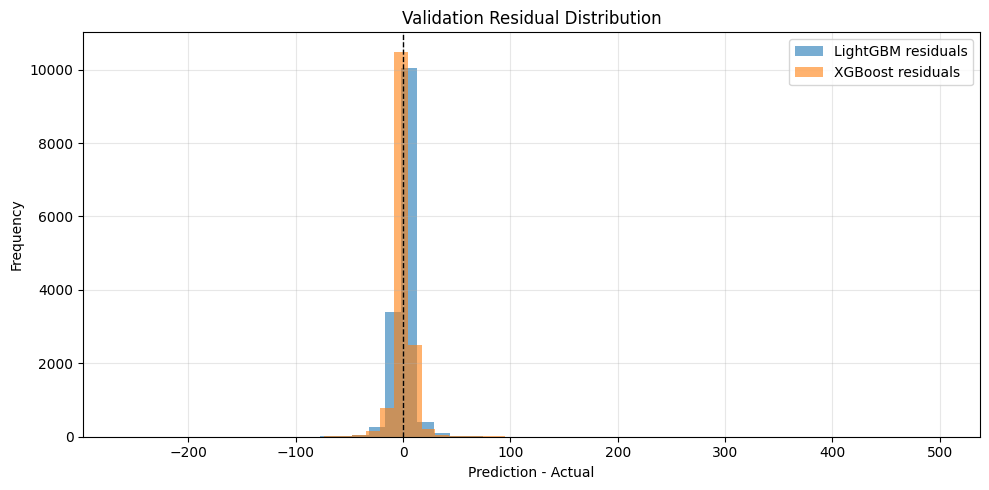

In [71]:
res_lgbm = lgbm_val_pred - y_val.values
res_xgb = xgb_val_pred - y_val.values

plt.figure(figsize=(10, 5))
plt.hist(res_lgbm, bins=50, alpha=0.6, label='LightGBM residuals')
plt.hist(res_xgb, bins=50, alpha=0.6, label='XGBoost residuals')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Validation Residual Distribution')
plt.xlabel('Prediction - Actual')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13) Final Test Evaluation
Evaluate the selected winner on the untouched test split.

Expected output: one-row final test KPI table for the winning model.

In [72]:
selected_model_name = winner_name_rolling if 'winner_name_rolling' in globals() else winner_name

pretest_df = pd.concat([train_df, val_df], ignore_index=True).copy()
X_pretest = pretest_df[feature_cols].copy()
y_pretest = pretest_df[target_col].astype(float).copy()

winner_model = build_model(selected_model_name) if 'build_model' in globals() else (lgbm_model if selected_model_name == 'LightGBM' else xgb_model)
winner_model.fit(X_pretest, y_pretest)
winner_test_pred = winner_model.predict(X_test)

winner_test_metrics = evaluate_metrics(
    y_test,
    winner_test_pred,
    model_name=selected_model_name,
    split_name='test',
    baseline_metrics=baseline_test
)

final_test_table = pd.DataFrame([winner_test_metrics])
final_test_table

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3725
[LightGBM] [Info] Number of data points in the train set: 83346, number of used features: 1455
[LightGBM] [Info] Start training from score 14.027932


,model,split,MAE,RMSE,SMAPE,BIAS,VA_MAE_pct,VA_SMAPE_pct
0,LightGBM,test,4.87158,9.744598,66.336148,0.459969,9.270237,-22.759544


## 14) Save Predictions and Metrics
Export validation/test predictions and KPI tables to reports.

Expected output: printed save paths for four CSV files in artifacts/reports.

In [73]:
val_predictions = val_df[['item_id', 'date', target_col]].copy()
val_predictions['pred_lgbm'] = lgbm_val_pred
val_predictions['pred_xgb'] = xgb_val_pred

test_predictions = test_df[['item_id', 'date', target_col]].copy()
test_predictions['pred_winner'] = winner_test_pred
test_predictions['winner_model'] = (winner_name_rolling if 'winner_name_rolling' in globals() else winner_name)

metrics_validation = rolling_summary.copy() if 'rolling_summary' in globals() else val_compare.copy()
metrics_test = final_test_table.copy()

val_predictions.to_csv(REPORTS_DIR / 'predictions_val_7d.csv', index=False)
test_predictions.to_csv(REPORTS_DIR / 'predictions_test_7d.csv', index=False)
metrics_validation.to_csv(REPORTS_DIR / 'metrics_validation_7d.csv', index=False)
metrics_test.to_csv(REPORTS_DIR / 'metrics_test_7d.csv', index=False)

if 'rolling_results' in globals():
    rolling_results.to_csv(REPORTS_DIR / 'metrics_validation_rolling_folds_7d.csv', index=False)

print('Saved:', REPORTS_DIR / 'predictions_val_7d.csv')
print('Saved:', REPORTS_DIR / 'predictions_test_7d.csv')
print('Saved:', REPORTS_DIR / 'metrics_validation_7d.csv')
print('Saved:', REPORTS_DIR / 'metrics_test_7d.csv')
if 'rolling_results' in globals():
    print('Saved:', REPORTS_DIR / 'metrics_validation_rolling_folds_7d.csv')

Saved: ..\artifacts\reports\predictions_val_7d.csv
Saved: ..\artifacts\reports\predictions_test_7d.csv
Saved: ..\artifacts\reports\metrics_validation_7d.csv
Saved: ..\artifacts\reports\metrics_test_7d.csv
Saved: ..\artifacts\reports\metrics_validation_rolling_folds_7d.csv


## 15) Build 3 Challenger Models and Append to 4-Combo CSV
Create three challenger test rows: blend (LGBM+XGB), tuned LGBM, tuned XGB, then append them to the existing 4-combo comparison file.

Expected output: a preview table with existing 4 rows + 3 challenger rows, saved to metrics_test_all_4combos_v1_v2.csv.

In [76]:
def _smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps))


def _bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))


def _evaluate_row(y_true, y_pred, baseline_pred, dataset_name, model_name):
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    smape_val = float(_smape(y_true, y_pred))
    bias_val = float(_bias(y_true, y_pred))

    baseline_mae = float(mean_absolute_error(y_true, baseline_pred))
    baseline_smape = float(_smape(y_true, baseline_pred))

    return {
        'dataset': dataset_name,
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'SMAPE': smape_val,
        'BIAS': bias_val,
        'VA_MAE_pct': 100.0 * (baseline_mae - mae) / baseline_mae if baseline_mae > 0 else np.nan,
        'VA_SMAPE_pct': 100.0 * (baseline_smape - smape_val) / baseline_smape if baseline_smape > 0 else np.nan,
    }


def _load_bundle(tag, version):
    data_dir = Path('../data/processed') / tag
    tr = pd.read_csv(data_dir / 'train.csv')
    va = pd.read_csv(data_dir / 'val.csv')
    te = pd.read_csv(data_dir / 'test.csv')

    for df in [tr, va, te]:
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'], errors='coerce')

    target = 'aggregated_sales_7'
    cat = ['item_id']
    event = [
        'event_christmas_7', 'event_easter_7', 'event_eid_al_fitr_7', 'event_eid_al_adha_7',
        'event_fathers_day_7', 'event_halloween_7', 'event_mothers_day_7', 'event_newyear_7',
        'event_orthodox_christmas_7', 'event_orthodox_easter_7', 'event_ramadan_starts_7',
        'event_thanksgiving_7', 'event_valentines_day_7'
    ]

    if version == 'v1':
        num = ['is_month_end', 'sales_lag_7', 'sales_roll_mean_7', 'aggregated_sell_price', 'discount_depth']
    else:
        num = [
            'is_month_end', 'sales_lag_7', 'sales_roll_mean_7', 'aggregated_sell_price', 'discount_depth',
            'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_roll_mean_2', 'sales_roll_mean_4',
            'sales_roll_std_4', 'price_lag_1', 'price_change_bucket', 'item_mean_train', 'item_std_train',
            'item_cv_train', 'weeks_since_first_seen'
        ]

    features = cat + num + event
    return {
        'train': tr,
        'val': va,
        'test': te,
        'target': target,
        'cat': cat,
        'num': num,
        'event': event,
        'features': features,
    }


def _build_tuned_pipeline(model_name, cat_features, num_features, event_features):
    prep = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
            ('num', 'passthrough', num_features + event_features),
        ],
        remainder='drop'
    )

    if model_name == 'ChallengerLGBM':
        reg = LGBMRegressor(
            random_state=RANDOM_SEED,
            n_estimators=900,
            learning_rate=0.03,
            num_leaves=63,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.10,
            reg_lambda=0.60,
        )
    elif model_name == 'ChallengerXGBoost':
        reg = XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=900,
            learning_rate=0.03,
            max_depth=8,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.10,
            reg_lambda=1.00,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    else:
        raise ValueError(f'Unknown challenger model: {model_name}')

    return Pipeline(steps=[('prep', prep), ('model', reg)])


def _run_challengers_for_bundle(bundle, challenger_dataset_name):
    train_df_local = bundle['train']
    val_df_local = bundle['val']
    test_df_local = bundle['test']
    features_local = bundle['features']
    target_local = bundle['target']

    X_tr = train_df_local[features_local].copy()
    y_tr = train_df_local[target_local].astype(float).copy()
    X_va = val_df_local[features_local].copy()
    y_va = val_df_local[target_local].astype(float).copy()
    X_te = test_df_local[features_local].copy()
    y_te = test_df_local[target_local].astype(float).copy()

    baseline_pred = X_te['sales_lag_7'].astype(float).values

    # Single-model challenger: tuned LGBM
    challenger_lgbm = _build_tuned_pipeline('ChallengerLGBM', bundle['cat'], bundle['num'], bundle['event'])
    challenger_lgbm.fit(pd.concat([X_tr, X_va], ignore_index=True), pd.concat([y_tr, y_va], ignore_index=True))
    pred_lgbm = challenger_lgbm.predict(X_te)
    row_lgbm = _evaluate_row(y_te, pred_lgbm, baseline_pred, challenger_dataset_name, 'ChallengerLGBM')

    # Single-model challenger: tuned XGB
    challenger_xgb = _build_tuned_pipeline('ChallengerXGBoost', bundle['cat'], bundle['num'], bundle['event'])
    challenger_xgb.fit(pd.concat([X_tr, X_va], ignore_index=True), pd.concat([y_tr, y_va], ignore_index=True))
    pred_xgb = challenger_xgb.predict(X_te)
    row_xgb = _evaluate_row(y_te, pred_xgb, baseline_pred, challenger_dataset_name, 'ChallengerXGBoost')

    # Blend challenger: choose weight on validation SMAPE
    blend_lgbm = _build_tuned_pipeline('ChallengerLGBM', bundle['cat'], bundle['num'], bundle['event'])
    blend_xgb = _build_tuned_pipeline('ChallengerXGBoost', bundle['cat'], bundle['num'], bundle['event'])
    blend_lgbm.fit(X_tr, y_tr)
    blend_xgb.fit(X_tr, y_tr)

    val_pred_lgbm = blend_lgbm.predict(X_va)
    val_pred_xgb = blend_xgb.predict(X_va)

    best_w = 0.5
    best_val_smape = np.inf
    for w in np.linspace(0.0, 1.0, 21):
        val_pred_blend = w * val_pred_xgb + (1.0 - w) * val_pred_lgbm
        s = _smape(y_va.values, val_pred_blend)
        if s < best_val_smape:
            best_val_smape = s
            best_w = float(w)

    blend_lgbm.fit(pd.concat([X_tr, X_va], ignore_index=True), pd.concat([y_tr, y_va], ignore_index=True))
    blend_xgb.fit(pd.concat([X_tr, X_va], ignore_index=True), pd.concat([y_tr, y_va], ignore_index=True))

    te_pred_lgbm = blend_lgbm.predict(X_te)
    te_pred_xgb = blend_xgb.predict(X_te)
    pred_blend = best_w * te_pred_xgb + (1.0 - best_w) * te_pred_lgbm
    row_blend = _evaluate_row(
        y_te,
        pred_blend,
        baseline_pred,
        challenger_dataset_name,
        f'ChallengerBlend_LGBM_XGB_w{best_w:.2f}'
    )

    rows = pd.DataFrame([row_blend, row_lgbm, row_xgb])
    return rows, best_w


bundle_v1 = _load_bundle('LGBM_XGB_7_V1', 'v1')
bundle_v2 = _load_bundle('LGBM_XGB_7_V2', 'v2')

challenger_rows_v1, best_w_v1 = _run_challengers_for_bundle(bundle_v1, 'CHALLENGER_V1')
challenger_rows_v2, best_w_v2 = _run_challengers_for_bundle(bundle_v2, 'CHALLENGER_V2')
challenger_rows = pd.concat([challenger_rows_v1, challenger_rows_v2], ignore_index=True)

comparison_path = REPORTS_DIR / 'metrics_test_all_4combos_v1_v2.csv'
fallback_path = REPORTS_DIR / 'metrics_test_all_4combos_v1_v2_updated.csv'
expected_cols = ['dataset', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'VA_MAE_pct', 'VA_SMAPE_pct']
if comparison_path.exists():
    compare_df = pd.read_csv(comparison_path)
else:
    compare_df = pd.DataFrame(columns=expected_cols)

for col in expected_cols:
    if col not in compare_df.columns:
        compare_df[col] = np.nan

compare_df = compare_df[expected_cols].copy()
# Keep only non-challenger base rows and add fresh challenger rows for V1 + V2.
compare_df = compare_df[~compare_df['dataset'].astype(str).str.startswith('CHALLENGER_')].copy()
updated_compare = pd.concat([compare_df, challenger_rows[expected_cols]], ignore_index=True)

saved_path = comparison_path
try:
    updated_compare.to_csv(comparison_path, index=False)
except PermissionError:
    saved_path = fallback_path
    updated_compare.to_csv(fallback_path, index=False)
    print('Main comparison file is locked. Close it and rerun to overwrite the main file.')

print('Best blend weight selected on validation (V1):', best_w_v1)
print('Best blend weight selected on validation (V2):', best_w_v2)
print('Saved:', saved_path)
updated_compare.sort_values(['SMAPE', 'MAE'], ascending=[True, True]).reset_index(drop=True)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3725
[LightGBM] [Info] Number of data points in the train set: 83346, number of used features: 1455
[LightGBM] [Info] Start training from score 14.027932
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3705
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 1454
[LightGBM] [Info] Start training from score 14.243998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3725
[LightGBM] [Info] Number of data points in the tra

,dataset,model,MAE,RMSE,SMAPE,BIAS,VA_MAE_pct,VA_SMAPE_pct
0,CHALLENGER_V2,ChallengerXGBoost,4.948366,9.845082,64.726573,1.130468,7.840167,-19.780918
1,LGBM_XGB_7_V2,XGBoost,4.976783,10.153773,64.737001,0.990327,7.310922,-19.800213
2,CHALLENGER_V2,ChallengerBlend_LGBM_XGB_w0.85,4.925753,9.749072,64.740418,1.120619,8.261312,-19.806537
3,LGBM_XGB_7_V2,LightGBM,4.896295,9.800620,65.117957,0.919454,8.809951,-20.505200
4,CHALLENGER_V2,ChallengerLGBM,4.943839,9.884209,65.152769,1.064807,7.924473,-20.569622
5,CHALLENGER_V1,ChallengerBlend_LGBM_XGB_w0.70,4.915243,10.156563,66.142393,0.483069,8.457053,-22.400989
6,CHALLENGER_V1,ChallengerLGBM,4.884881,9.781242,66.201687,0.521330,9.022520,-22.510715
7,CHALLENGER_V1,ChallengerXGBoost,5.008221,10.726797,66.234311,0.466671,6.725410,-22.571088
8,LGBM_XGB_7_V1,LightGBM,4.871580,9.744598,66.336148,0.459969,9.270237,-22.759544
9,LGBM_XGB_7_V1,XGBoost,5.015826,10.819849,66.653288,0.417345,6.583773,-23.346433


## 16) Presentation Plots for the Selected 10-Model Comparison
Build presentation-ready plots for all 10 models (4 base + 6 challengers) and show dataset-specific benchmarks.

Expected output: three visual blocks: KPI comparison with benchmark markers, actual-vs-predicted curves, and validation residual distributions.

In [ ]:
# Prepare plot-ready data for all 10 models (4 base + 6 challengers).

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

if 'RANDOM_SEED' not in globals():
    RANDOM_SEED = 42
if 'REPORTS_DIR' not in globals():
    REPORTS_DIR = Path('../artifacts/reports')


def _smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps))


def _bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))


def _load_bundle(tag, version):
    data_dir = Path('../data/processed') / tag
    tr = pd.read_csv(data_dir / 'train.csv')
    va = pd.read_csv(data_dir / 'val.csv')
    te = pd.read_csv(data_dir / 'test.csv')

    for df in [tr, va, te]:
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'], errors='coerce')

    target = 'aggregated_sales_7'
    cat = ['item_id']
    event = [
        'event_christmas_7', 'event_easter_7', 'event_eid_al_fitr_7', 'event_eid_al_adha_7',
        'event_fathers_day_7', 'event_halloween_7', 'event_mothers_day_7', 'event_newyear_7',
        'event_orthodox_christmas_7', 'event_orthodox_easter_7', 'event_ramadan_starts_7',
        'event_thanksgiving_7', 'event_valentines_day_7'
    ]

    if version == 'v1':
        num = ['is_month_end', 'sales_lag_7', 'sales_roll_mean_7', 'aggregated_sell_price', 'discount_depth']
    else:
        num = [
            'is_month_end', 'sales_lag_7', 'sales_roll_mean_7', 'aggregated_sell_price', 'discount_depth',
            'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_roll_mean_2', 'sales_roll_mean_4',
            'sales_roll_std_4', 'price_lag_1', 'price_change_bucket', 'item_mean_train', 'item_std_train',
            'item_cv_train', 'weeks_since_first_seen'
        ]

    features = cat + num + event
    return {
        'train': tr,
        'val': va,
        'test': te,
        'target': target,
        'cat': cat,
        'num': num,
        'event': event,
        'features': features,
    }


def _dataset_key(label):
    label = str(label)
    if 'V1' in label:
        return 'V1'
    if 'V2' in label:
        return 'V2'
    return 'UNKNOWN'


def _display_name(dataset_label, model_name):
    return f"{dataset_label} | {model_name}"


def _build_model_by_kind(kind, cat_features, num_features, event_features):
    prep = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
            ('num', 'passthrough', num_features + event_features),
        ],
        remainder='drop'
    )

    if kind == 'base_lgbm':
        reg = LGBMRegressor(
            random_state=RANDOM_SEED,
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
        )
    elif kind == 'base_xgb':
        reg = XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    elif kind == 'ch_lgbm':
        reg = LGBMRegressor(
            random_state=RANDOM_SEED,
            n_estimators=900,
            learning_rate=0.03,
            num_leaves=63,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.10,
            reg_lambda=0.60,
        )
    elif kind == 'ch_xgb':
        reg = XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=900,
            learning_rate=0.03,
            max_depth=8,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.10,
            reg_lambda=1.00,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    else:
        raise ValueError(f'Unknown model kind: {kind}')

    return Pipeline(steps=[('prep', prep), ('model', reg)])


def _choose_blend_weight_on_val(bundle, left_kind, right_kind):
    tr = bundle['train']
    va = bundle['val']
    feats = bundle['features']
    tgt = bundle['target']

    X_tr = tr[feats].copy()
    y_tr = tr[tgt].astype(float).copy()
    X_va = va[feats].copy()
    y_va = va[tgt].astype(float).copy()

    m_left = _build_model_by_kind(left_kind, bundle['cat'], bundle['num'], bundle['event'])
    m_right = _build_model_by_kind(right_kind, bundle['cat'], bundle['num'], bundle['event'])
    m_left.fit(X_tr, y_tr)
    m_right.fit(X_tr, y_tr)

    p_left = m_left.predict(X_va)
    p_right = m_right.predict(X_va)

    best_w = 0.5
    best_s = np.inf
    for w in np.linspace(0.0, 1.0, 21):
        p = w * p_right + (1.0 - w) * p_left
        s = _smape(y_va.values, p)
        if s < best_s:
            best_s = s
            best_w = float(w)

    return best_w


# Force using the user-specified file first.
compare_alt = REPORTS_DIR / 'metrics_test_all_4combos_v1_v2_updated.csv'
compare_main = REPORTS_DIR / 'metrics_test_all_4combos_v1_v2.csv'

if compare_alt.exists():
    comparison_df = pd.read_csv(compare_alt)
elif compare_main.exists():
    comparison_df = pd.read_csv(compare_main)
else:
    raise FileNotFoundError('No comparison CSV found in artifacts/reports.')

# Normalize expected columns and ignore extra columns like `id` if present.
expected_cols = ['dataset', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'VA_MAE_pct', 'VA_SMAPE_pct']
for col in expected_cols:
    if col not in comparison_df.columns:
        raise ValueError(f'Missing required column in comparison CSV: {col}')
comparison_df = comparison_df[expected_cols].copy()
comparison_df = comparison_df.drop_duplicates(subset=['dataset', 'model']).copy()

bundle_v1_plot = _load_bundle('LGBM_XGB_7_V1', 'v1')
bundle_v2_plot = _load_bundle('LGBM_XGB_7_V2', 'v2')

benchmark_map = {}
for ds_key, bundle in [('V1', bundle_v1_plot), ('V2', bundle_v2_plot)]:
    y_true_b = bundle['test'][bundle['target']].astype(float).values
    y_pred_b = bundle['test']['sales_lag_7'].astype(float).values
    benchmark_map[ds_key] = {
        'MAE': float(mean_absolute_error(y_true_b, y_pred_b)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_b, y_pred_b))),
        'SMAPE': float(_smape(y_true_b, y_pred_b)),
        'BIAS_abs': float(abs(_bias(y_true_b, y_pred_b))),
    }

kpi_plot_df = comparison_df.copy()
kpi_plot_df['dataset_key'] = kpi_plot_df['dataset'].map(_dataset_key)
kpi_plot_df['BIAS_abs'] = kpi_plot_df['BIAS'].abs()
kpi_plot_df['display'] = kpi_plot_df.apply(lambda r: _display_name(r['dataset'], r['model']), axis=1)
kpi_plot_df['bench_MAE'] = kpi_plot_df['dataset_key'].map(lambda k: benchmark_map[k]['MAE'])
kpi_plot_df['bench_RMSE'] = kpi_plot_df['dataset_key'].map(lambda k: benchmark_map[k]['RMSE'])
kpi_plot_df['bench_SMAPE'] = kpi_plot_df['dataset_key'].map(lambda k: benchmark_map[k]['SMAPE'])
kpi_plot_df['bench_BIAS_abs'] = kpi_plot_df['dataset_key'].map(lambda k: benchmark_map[k]['BIAS_abs'])

# Build predictions for curve and residual plots.
curve_rows = []
residual_rows = []

for ds_key, bundle in [('V1', bundle_v1_plot), ('V2', bundle_v2_plot)]:
    ds_name_base = f'LGBM_XGB_7_{ds_key}'
    ds_name_ch = f'CHALLENGER_{ds_key}'

    feats = bundle['features']
    target = bundle['target']

    tr = bundle['train']
    va = bundle['val']
    te = bundle['test']

    X_tr = tr[feats].copy()
    y_tr = tr[target].astype(float).copy()
    X_va = va[feats].copy()
    y_va = va[target].astype(float).copy()
    X_pre = pd.concat([tr, va], ignore_index=True)[feats].copy()
    y_pre = pd.concat([tr, va], ignore_index=True)[target].astype(float).copy()
    X_te = te[feats].copy()
    y_te = te[target].astype(float).copy()

    model_specs = [
        (ds_name_base, 'LightGBM', 'base_lgbm', None),
        (ds_name_base, 'XGBoost', 'base_xgb', None),
        (ds_name_ch, 'ChallengerLGBM', 'ch_lgbm', None),
        (ds_name_ch, 'ChallengerXGBoost', 'ch_xgb', None),
    ]

    for ds_label, model_label, kind, _ in model_specs:
        m_val = _build_model_by_kind(kind, bundle['cat'], bundle['num'], bundle['event'])
        m_test = _build_model_by_kind(kind, bundle['cat'], bundle['num'], bundle['event'])

        m_val.fit(X_tr, y_tr)
        p_val = m_val.predict(X_va)
        m_test.fit(X_pre, y_pre)
        p_test = m_test.predict(X_te)

        name = _display_name(ds_label, model_label)
        residual_rows.append(pd.DataFrame({
            'dataset_key': ds_key,
            'display': name,
            'residual': p_val - y_va.values,
        }))

        tmp_curve = te[['date']].copy()
        tmp_curve['date'] = pd.to_datetime(tmp_curve['date'], errors='coerce')
        tmp_curve['actual'] = y_te.values
        tmp_curve['pred'] = p_test
        tmp_curve = tmp_curve.groupby('date', as_index=False)[['actual', 'pred']].mean()
        tmp_curve['dataset_key'] = ds_key
        tmp_curve['display'] = name
        curve_rows.append(tmp_curve)

    w_blend = _choose_blend_weight_on_val(bundle, 'ch_lgbm', 'ch_xgb')

    blend_val_l = _build_model_by_kind('ch_lgbm', bundle['cat'], bundle['num'], bundle['event'])
    blend_val_x = _build_model_by_kind('ch_xgb', bundle['cat'], bundle['num'], bundle['event'])
    blend_val_l.fit(X_tr, y_tr)
    blend_val_x.fit(X_tr, y_tr)
    p_val_blend = w_blend * blend_val_x.predict(X_va) + (1.0 - w_blend) * blend_val_l.predict(X_va)

    blend_test_l = _build_model_by_kind('ch_lgbm', bundle['cat'], bundle['num'], bundle['event'])
    blend_test_x = _build_model_by_kind('ch_xgb', bundle['cat'], bundle['num'], bundle['event'])
    blend_test_l.fit(X_pre, y_pre)
    blend_test_x.fit(X_pre, y_pre)
    p_test_blend = w_blend * blend_test_x.predict(X_te) + (1.0 - w_blend) * blend_test_l.predict(X_te)

    blend_label = _display_name(ds_name_ch, f'ChallengerBlend_LGBM_XGB_w{w_blend:.2f}')
    residual_rows.append(pd.DataFrame({
        'dataset_key': ds_key,
        'display': blend_label,
        'residual': p_val_blend - y_va.values,
    }))

    tmp_curve_bl = te[['date']].copy()
    tmp_curve_bl['date'] = pd.to_datetime(tmp_curve_bl['date'], errors='coerce')
    tmp_curve_bl['actual'] = y_te.values
    tmp_curve_bl['pred'] = p_test_blend
    tmp_curve_bl = tmp_curve_bl.groupby('date', as_index=False)[['actual', 'pred']].mean()
    tmp_curve_bl['dataset_key'] = ds_key
    tmp_curve_bl['display'] = blend_label
    curve_rows.append(tmp_curve_bl)

curve_plot_df = pd.concat(curve_rows, ignore_index=True)
residual_plot_df = pd.concat(residual_rows, ignore_index=True)

print('Using metrics source:', compare_alt if compare_alt.exists() else compare_main)
print('Prepared rows for KPI plot:', len(kpi_plot_df))
print('Prepared rows for curve plot:', len(curve_plot_df))
print('Prepared rows for residual plot:', len(residual_plot_df))

In [ ]:
# Plot 1: KPI comparison for all 10 models with dataset-specific benchmark markers.

plot_kpi = kpi_plot_df.sort_values(['SMAPE', 'MAE'], ascending=[True, True]).reset_index(drop=True)
y_pos = np.arange(len(plot_kpi))

fig, axes = plt.subplots(1, 4, figsize=(24, max(8, len(plot_kpi) * 0.45)), sharey=True)
metrics_and_bench = [
    ('MAE', 'bench_MAE', 'MAE'),
    ('RMSE', 'bench_RMSE', 'RMSE'),
    ('SMAPE', 'bench_SMAPE', 'SMAPE'),
    ('BIAS_abs', 'bench_BIAS_abs', '|BIAS|'),
]

for ax, (metric_col, bench_col, title) in zip(axes, metrics_and_bench):
    colors = ['#3b82f6' if k == 'V1' else '#f97316' for k in plot_kpi['dataset_key']]
    ax.barh(y_pos, plot_kpi[metric_col], color=colors, alpha=0.75)
    ax.scatter(plot_kpi[bench_col], y_pos, marker='D', color='black', s=30, label='NaiveLag7 benchmark')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(plot_kpi['display'])
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')

fig.suptitle('KPI Comparison for 10 Models (with Benchmark Markers)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 2: Actual vs predicted curves for all 10 models.
# To keep the view simple, curves are aggregated by date (mean across items).

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
for ax, ds_key in zip(axes, ['V1', 'V2']):
    d = curve_plot_df[curve_plot_df['dataset_key'] == ds_key].copy()
    actual_by_date = d[['date', 'actual']].drop_duplicates().sort_values('date')

    ax.plot(actual_by_date['date'], actual_by_date['actual'], color='black', linewidth=2.5, label='Actual')

    for name, g in d.groupby('display'):
        g = g.sort_values('date')
        ax.plot(g['date'], g['pred'], alpha=0.8, linewidth=1.3, label=name)

    ax.set_title(f'Actual vs Predicted Curves ({ds_key} models)')
    ax.set_ylabel('aggregated_sales_7')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', ncol=2, fontsize=8)

axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

In [ ]:
# Plot 3: Validation residual distribution for all 10 models.

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
for ax, ds_key in zip(axes, ['V1', 'V2']):
    d = residual_plot_df[residual_plot_df['dataset_key'] == ds_key].copy()

    for name, g in d.groupby('display'):
        ax.hist(g['residual'], bins=45, alpha=0.35, density=True, label=name)

    ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f'Validation Residual Distribution ({ds_key} models)')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Prediction - Actual')
plt.tight_layout()
plt.show()

## Interpretation Template

After running all cells, summarize:
1. Which model won on validation and why (SMAPE first, then RMSE, then BIAS).
2. Final test KPIs for the selected model.
3. Whether forecast bias is acceptable for business usage.
4. Next action: replicate the same pipeline for 14-day and 21-day windows.